# Single-Qubit Gates

This notebook explores single-qubit gates: I, X, Z, Y, H, S, and T.

- **Measurement-based** tests run many shots and show outcome distributions.
- **State inspection** tests use `DumpMachine()` to examine amplitudes and phases.

In [8]:
import qsharp
import matplotlib.pyplot as plt

In [ ]:
qsharp.init()
with open("Program.qs") as f:
    qsharp.eval(f.read())

from qsharp.code import MeasureI, MeasureX, MeasureHZH
from qsharp.code import DumpZ0, DumpZ1, DumpY0, DumpY1
from qsharp.code import DumpS1, DumpSAdjS1, DumpT4on1

## Measurement-based tests

- **I gate**: identity, qubit stays in $|0\rangle$ - always measures `Zero`.
- **X gate**: bit-flip, qubit goes to $|1\rangle$ - always measures `One`.
- **HZH**: equivalent to X gate - always measures `One`.

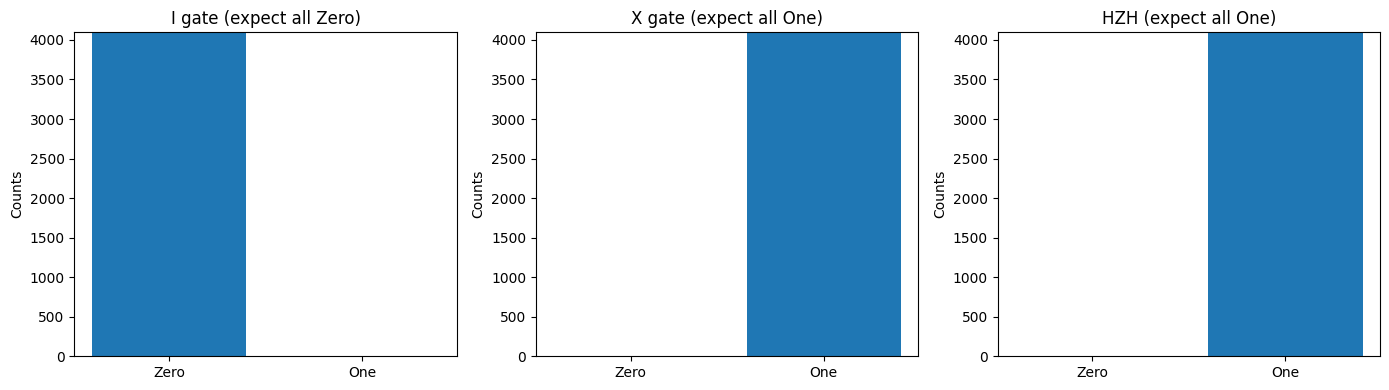

In [10]:
shots = 4096

experiments = {
    "I gate (expect all Zero)": MeasureI,
    "X gate (expect all One)": MeasureX,
    "HZH (expect all One)": MeasureHZH,
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (title, op) in zip(axes, experiments.items()):
    results = [str(op()) for _ in range(shots)]
    counts = {"Zero": results.count("Zero"), "One": results.count("One")}
    ax.bar(counts.keys(), counts.values())
    ax.set_title(title)
    ax.set_ylabel("Counts")
    ax.set_ylim(0, shots)

plt.tight_layout()
plt.show()

## State inspection with DumpMachine

### Z gate

Z applied to $|0\rangle$ has no visible effect (global phase). Z applied to $|1\rangle$ flips the phase to $-|1\rangle$.

In [ ]:
print("Z|0>:")
DumpZ0()

print("\nZ|1>:")
DumpZ1()

### Y gate

Y applied to $|0\rangle$ gives $i|1\rangle$. Y applied to $|1\rangle$ gives $-i|0\rangle$.

In [ ]:
print("Y|0>:")
DumpY0()

print("\nY|1>:")
DumpY1()

### S gate

S applied to $|1\rangle$ gives $i|1\rangle$. Applying $S^\dagger$ reverses it.

In [ ]:
print("S|1>:")
DumpS1()

print("\nS^dag S|1> (back to |1>):")
DumpSAdjS1()

### T gate and T-Z relationship

$T^4 = Z$: applying T four times to $|1\rangle$ produces $-|1\rangle$, same as Z.

In [ ]:
print("T^4|1> (same as Z|1>):")
DumpT4on1()